In [1]:
# !pip install growwapi
# !pip install --upgrade growwapi
# !pip install pyarrow fastparquet
# !pip install --upgrade scipy statsmodels
# !pip install scipy==1.10.1 statsmodels==0.14.0

In [2]:
import pandas as pd
import numpy as np
import math
from itertools import combinations
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from growwapi import GrowwAPI

In [3]:
API_Key = "eyJraWQiOiJaTUtjVXciLCJhbGciOiJFUzI1NiJ9.eyJleHAiOjI1NjM4NDU1MTQsImlhdCI6MTc3NTQ0NTUxNCwibmJmIjoxNzc1NDQ1NTE0LCJzdWIiOiJ7XCJ0b2tlblJlZklkXCI6XCI1YThlOWU5MC02MGNjLTQ1NDUtODY1Yi0yZmI0MDdhODRhMTNcIixcInZlbmRvckludGVncmF0aW9uS2V5XCI6XCJlMzFmZjIzYjA4NmI0MDZjODg3NGIyZjZkODQ5NTMxM1wiLFwidXNlckFjY291bnRJZFwiOlwiODdlODE1ZjAtZWM5MS00OTU4LWIwNzUtMDg0MWMyMTk2MzNkXCIsXCJkZXZpY2VJZFwiOlwiNTEyN2ZiZjktMTZiMS01NzUzLTk2MjgtOTQyMTQwNGJhZDYwXCIsXCJzZXNzaW9uSWRcIjpcIjlhZjlkYTc1LWFkNGQtNGM3NS1hMjZjLWRkMTc0OThhYTc5MVwiLFwiYWRkaXRpb25hbERhdGFcIjpcIno1NC9NZzltdjE2WXdmb0gvS0EwYkFvc2NJMXRRNzBlTXdSeHhOa1IxMTlSTkczdTlLa2pWZDNoWjU1ZStNZERhWXBOVi9UOUxIRmtQejFFQisybTdRPT1cIixcInJvbGVcIjpcImF1dGgtdG90cFwiLFwic291cmNlSXBBZGRyZXNzXCI6XCI0OS4yNDguMTAyLjE1OCwxNzIuNzEuMTk4Ljk0LDM1LjI0MS4yMy4xMjNcIixcInR3b0ZhRXhwaXJ5VHNcIjoyNTYzODQ1NTE0NzI0LFwidmVuZG9yTmFtZVwiOlwiZ3Jvd3dBcGlcIn0iLCJpc3MiOiJhcGV4LWF1dGgtcHJvZC1hcHAifQ.bgjJsha_GiSnbd3cu0Gl9chkWYJyD_qhlEJyz1ujdZbxFOHfrnE8yY0NEFYlYuKoK4f4fOGoHt1_zbiu4O1n6Q"
Secret_Key = "g0VR3jBal&rZld$s%faywsSLJsDcCj$R"

In [4]:
access_token = GrowwAPI.get_access_token(api_key=API_Key, secret=Secret_Key)
# Use access_token to initiate GrowwAPI
groww = GrowwAPI(access_token)

Ready to Groww!


In [5]:
symbol_segment_map = {'RELIANCE': 'Oil Gas & Consumable Fuels', 'HDFCBANK': 'Financial Services', 
                      'ICICIBANK': 'Financial Services', 'INFY': 'Information Technology', 'TCS': 'Information Technology',
                      'HINDUNILVR': 'FMCG', 'ITC': 'FMCG', 'BHARTIARTL': 'Telecommunication', 'SBIN': 'Financial Services',
                      'KOTAKBANK': 'Financial Services', 'AXISBANK': 'Financial Services', 'BAJFINANCE': 'Financial Services',
                      'BAJAJFINSV': 'Financial Services', 'HCLTECH': 'Information Technology', 
                      'WIPRO': 'Information Technology', 'LTIM': 'Information Technology', 'TECHM': 'Information Technology',
                      'LT': 'Construction', 'ULTRACEMCO': 'Construction Materials', 'GRASIM': 'Construction Materials', 
                      'SHREECEM': 'Construction Materials', 'TATASTEEL': 'Metals & Mining', 'JSWSTEEL': 'Metals & Mining', 
                      'HINDALCO': 'Metals & Mining', 'COALINDIA': 'Oil Gas & Consumable Fuels', 
                      'ONGC': 'Oil Gas & Consumable Fuels', 'POWERGRID': 'Power', 'NTPC': 'Power', 
                      'ADANIENT': 'Diversified', 'ADANIPORTS': 'Services', 'ASIANPAINT': 'Consumer Durables', 
                      'TITAN': 'Consumer Durables', 'NESTLEIND': 'FMCG', 'BRITANNIA': 'FMCG', 'MARUTI': 'Automobile', 
                      'M&M': 'Automobile', 'TATAMOTORS': 'Automobile', 'BAJAJ-AUTO': 'Automobile', 
                      'HEROMOTOCO': 'Automobile', 'EICHERMOT': 'Automobile', 'APOLLOHOSP': 'Healthcare', 
                      'SUNPHARMA': 'Healthcare', 'DRREDDY': 'Healthcare', 'CIPLA': 'Healthcare', 'DIVISLAB': 'Healthcare', 
                      'UPL': 'Chemicals', 'SBILIFE': 'Financial Services', 'HDFCLIFE': 'Financial Services', 
                      'SBICARD': 'Financial Services', 'INDUSINDBK': 'Financial Services'}


### Historical Data Storing

In [6]:
def get_historical_data(start_date, end_date, symbol="RELIANCE"):
    historical_data_response = groww.get_historical_candles(
        groww_symbol=f"NSE-{symbol.upper()}",
        exchange=groww.EXCHANGE_NSE,
        segment=groww.SEGMENT_CASH,
        start_time=start_date,
        end_time=end_date,
        candle_interval=groww.CANDLE_INTERVAL_DAY # Optional: Interval in days for the candle data
    )
    return historical_data_response

In [7]:
def fetch_and_store_hist_data(symbol):    
    file_path = os.path.join(os.getcwd(), f"{symbol}_Hist_Data.csv")
    
    if os.path.exists(file_path):
        print(f"Data already exists for {symbol}")
        
    else:
        start_date = pd.to_datetime('2020-01-01')
        end_date = pd.to_datetime('2026-01-01')
        total_days = end_date - start_date
        data_list = []
        while total_days > timedelta(days=0):
            intermediate_end_date = start_date + timedelta(days=180) if total_days > timedelta(days=180) else start_date + timedelta(days=total_days.days)
            print(start_date, " => ", intermediate_end_date)
            hist_data = get_historical_data(start_date, intermediate_end_date, symbol)
            print(hist_data["candles"], '\n\n')
            if hist_data["candles"]:
                data_list.append(hist_data["candles"])
            start_date = intermediate_end_date
            total_days = total_days - timedelta(days=180)
        #     print(total_days, '\n')

        data_list = np.concatenate(data_list)
        data_list

        df = pd.DataFrame(
            data_list,
            columns=["Date", "Open", "High", "Low", "Close", "Volume", "Extra"]
        )

        df.to_csv(f"{symbol}_Hist_Data.csv")

In [8]:
# stock_df = fetch_and_store_hist_data("LTIM")
# stock_df

### Data Merging

In [9]:
df_list = []
for symbol in symbol_segment_map.keys():
    df = pd.read_csv(f"{symbol}_Hist_Data.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)
    
    # remove duplicate dates
    df = df[~df.index.duplicated(keep="first")]
    
    new_df = df["Close"].rename(symbol)
    df_list.append(new_df)


merged_df = pd.concat(df_list, axis=1)
merged_df.to_csv("Merged_Data.csv")

In [10]:
# merged_df

### Data Cleaning

In [11]:
merged_df = pd.read_csv("Merged_Data.csv", index_col="Date", parse_dates=True)
merged_df = merged_df.ffill()
merged_df = merged_df.dropna()

In [12]:
for col in merged_df.columns:
    col_value_count = merged_df[col].notna().sum()
    if col_value_count < 1490:
        print(col, " => ", col_value_count)

RELIANCE  =>  764
HDFCBANK  =>  764
ICICIBANK  =>  764
INFY  =>  764
TCS  =>  764
HINDUNILVR  =>  764
ITC  =>  764
BHARTIARTL  =>  764
SBIN  =>  764
KOTAKBANK  =>  764
AXISBANK  =>  764
BAJFINANCE  =>  764
BAJAJFINSV  =>  764
HCLTECH  =>  764
WIPRO  =>  764
LTIM  =>  764
TECHM  =>  764
LT  =>  764
ULTRACEMCO  =>  764
GRASIM  =>  764
SHREECEM  =>  764
TATASTEEL  =>  764
JSWSTEEL  =>  764
HINDALCO  =>  764
COALINDIA  =>  764
ONGC  =>  764
POWERGRID  =>  764
NTPC  =>  764
ADANIENT  =>  764
ADANIPORTS  =>  764
ASIANPAINT  =>  764
TITAN  =>  764
NESTLEIND  =>  764
BRITANNIA  =>  764
MARUTI  =>  764
M&M  =>  764
TATAMOTORS  =>  764
BAJAJ-AUTO  =>  764
HEROMOTOCO  =>  764
EICHERMOT  =>  764
APOLLOHOSP  =>  764
SUNPHARMA  =>  764
DRREDDY  =>  764
CIPLA  =>  764
DIVISLAB  =>  764
UPL  =>  764
SBILIFE  =>  764
HDFCLIFE  =>  764
SBICARD  =>  764
INDUSINDBK  =>  764


In [13]:
# merged_df.drop(["LTIM", "TATAMOTORS", "SBICARD"], axis=1, inplace=True)

In [14]:
merged_df = merged_df.ffill()

In [66]:
train_df = merged_df.loc[:'2023-12-31']
test_df = merged_df.loc['2024-01-01':]

### Returns Data

In [67]:
training_returns = np.log(train_df / train_df.shift(1)).fillna(0)
training_returns

,RELIANCE,HDFCBANK,ICICIBANK,INFY,TCS,HINDUNILVR,ITC,BHARTIARTL,SBIN,KOTAKBANK,...,APOLLOHOSP,SUNPHARMA,DRREDDY,CIPLA,DIVISLAB,UPL,SBILIFE,HDFCLIFE,SBICARD,INDUSINDBK
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-12-06,0.002885,-0.001117,-0.011798,-0.016510,-0.011907,0.013158,0.001632,-0.012817,-0.013619,-0.001652,...,0.002028,-0.005644,-0.022917,-0.005169,-0.003851,-0.018734,0.000428,-0.003572,-0.016437,-0.009582
2022-12-07,-0.014867,-0.000435,-0.000542,-0.004599,-0.001404,0.019695,0.008267,0.000780,-0.003125,-0.012374,...,-0.012748,-0.015405,-0.002908,-0.003883,-0.005273,-0.012452,-0.018099,-0.008557,-0.007550,-0.016562
2022-12-08,-0.000472,0.005604,0.010518,0.009084,-0.008929,-0.000702,-0.005011,-0.001680,0.007549,-0.007588,...,-0.004856,-0.036981,-0.001216,0.001988,-0.015335,-0.000386,0.003796,-0.007418,0.003813,0.022247
2022-12-09,-0.015271,0.007107,-0.002148,-0.031889,-0.017401,0.006190,0.008826,0.002759,0.007898,-0.004729,...,-0.004132,0.012211,0.011617,0.000361,-0.004084,-0.018359,0.002208,0.003630,-0.016276,0.009735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,0.000975,-0.009441,-0.010107,0.017361,0.009591,0.008735,0.008272,0.011843,-0.010933,0.004201,...,0.011647,0.008195,0.013092,0.011191,0.016991,0.007334,-0.006755,-0.006775,0.010336,-0.004885
2023-12-26,0.005055,0.006919,0.000804,-0.012199,-0.007468,0.003546,0.002742,0.010355,0.002040,0.014064,...,0.016674,0.003091,0.000790,0.007539,0.044606,0.007622,0.000717,-0.002895,-0.006553,0.005394
2023-12-27,0.003408,0.012316,0.007160,0.014883,0.004115,0.009070,0.001423,0.021128,0.016322,0.008181,...,0.009593,0.003960,0.014516,-0.004186,0.005356,-0.004960,0.018498,0.009050,-0.004371,0.016824


### Correlation

In [16]:
corr_matrix = training_returns.corr()
corr_matrix

,RELIANCE,HDFCBANK,ICICIBANK,INFY,TCS,HINDUNILVR,ITC,BHARTIARTL,SBIN,KOTAKBANK,...,APOLLOHOSP,SUNPHARMA,DRREDDY,CIPLA,DIVISLAB,UPL,SBILIFE,HDFCLIFE,SBICARD,INDUSINDBK
RELIANCE,1.000000,0.095409,0.084979,0.113181,0.098742,0.009881,0.116000,0.156182,0.179722,0.164682,...,0.106946,0.046322,0.887850,0.054863,0.061494,0.102421,0.159569,0.085928,0.178957,0.100722
HDFCBANK,0.095409,1.000000,0.228187,0.082025,0.045108,-0.030948,0.044223,0.132218,0.175591,0.181624,...,0.080393,0.145562,0.028093,0.063591,0.052962,0.116345,0.140522,0.122113,0.134688,0.129651
ICICIBANK,0.084979,0.228187,1.000000,0.239594,0.202979,0.071456,0.255616,0.331622,0.454382,0.412732,...,0.156988,0.159244,-0.076590,0.101763,0.060430,0.225428,0.249045,0.221098,0.239946,0.180743
INFY,0.113181,0.082025,0.239594,1.000000,0.706942,0.178001,0.127055,0.260150,0.152914,0.152658,...,0.133547,0.143338,0.043299,0.153943,0.144936,0.183525,0.196263,0.123261,0.188296,0.140397
TCS,0.098742,0.045108,0.202979,0.706942,1.000000,0.160594,0.142961,0.221853,0.175741,0.133517,...,0.143616,0.167856,0.020235,0.144867,0.123434,0.190959,0.189607,0.128452,0.126148,0.098853
HINDUNILVR,0.009881,-0.030948,0.071456,0.178001,0.160594,1.000000,0.336065,0.140858,-0.008288,0.158190,...,0.140136,0.080218,-0.047252,0.103407,0.050846,0.088751,0.192994,0.104256,0.071817,0.059275
ITC,0.116000,0.044223,0.255616,0.127055,0.142961,0.336065,1.000000,0.196386,0.227716,0.232785,...,0.117511,0.149609,0.022257,0.135056,0.086375,0.155281,0.116979,0.096601,0.116174,0.088410
BHARTIARTL,0.156182,0.132218,0.331622,0.260150,0.221853,0.140858,0.196386,1.000000,0.250467,0.287628,...,0.218674,0.253473,0.042680,0.133528,0.139123,0.250509,0.268758,0.209057,0.181401,0.163241
SBIN,0.179722,0.175591,0.454382,0.152914,0.175741,-0.008288,0.227716,0.250467,1.000000,0.331253,...,0.177202,0.144271,-0.002135,0.099878,0.077575,0.317408,0.305401,0.249317,0.292362,0.346965
KOTAKBANK,0.164682,0.181624,0.412732,0.152658,0.133517,0.158190,0.232785,0.287628,0.331253,1.000000,...,0.170617,0.128803,0.039821,0.071249,0.102690,0.198064,0.239371,0.187752,0.277060,0.198444


<Axes: >

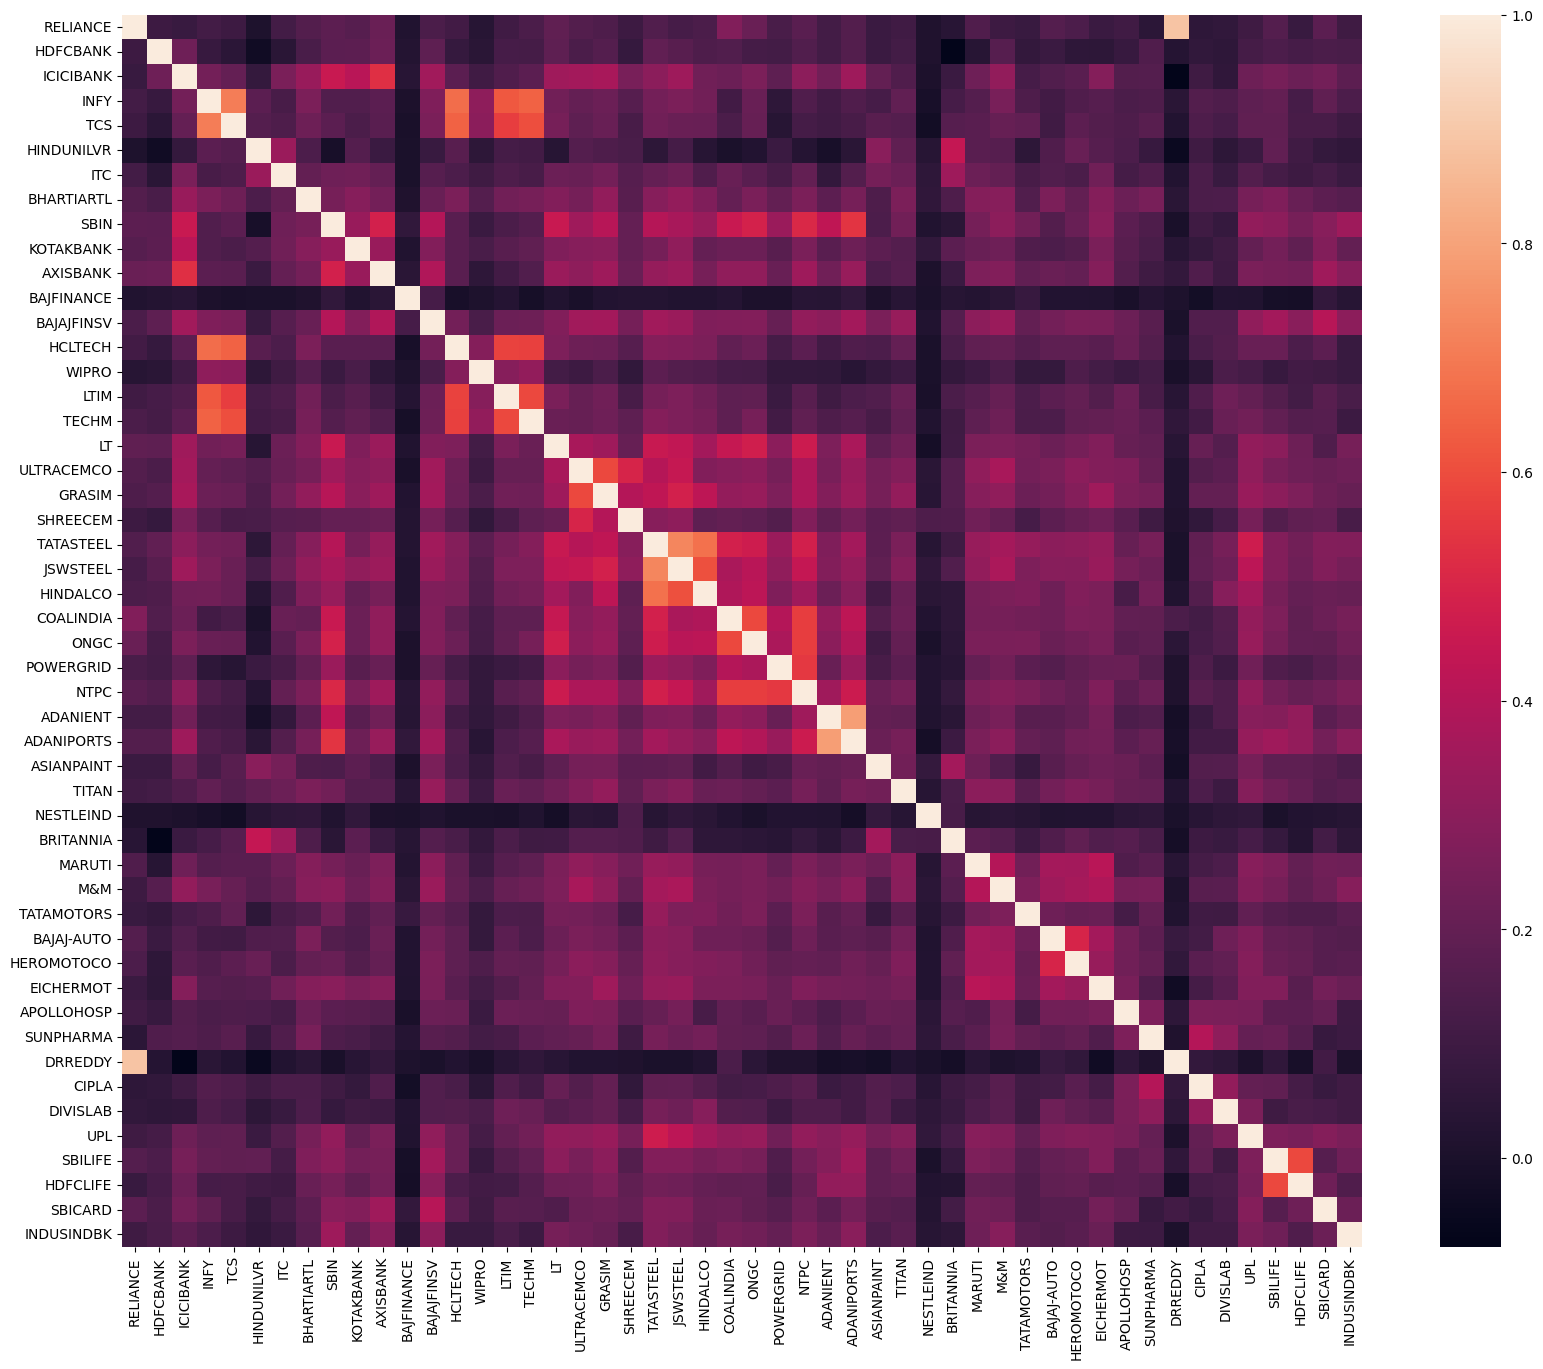

In [17]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix)

In [18]:
corr_matrix.columns

Index(['RELIANCE', 'HDFCBANK', 'ICICIBANK', 'INFY', 'TCS', 'HINDUNILVR', 'ITC',
       'BHARTIARTL', 'SBIN', 'KOTAKBANK', 'AXISBANK', 'BAJFINANCE',
       'BAJAJFINSV', 'HCLTECH', 'WIPRO', 'LTIM', 'TECHM', 'LT', 'ULTRACEMCO',
       'GRASIM', 'SHREECEM', 'TATASTEEL', 'JSWSTEEL', 'HINDALCO', 'COALINDIA',
       'ONGC', 'POWERGRID', 'NTPC', 'ADANIENT', 'ADANIPORTS', 'ASIANPAINT',
       'TITAN', 'NESTLEIND', 'BRITANNIA', 'MARUTI', 'M&M', 'TATAMOTORS',
       'BAJAJ-AUTO', 'HEROMOTOCO', 'EICHERMOT', 'APOLLOHOSP', 'SUNPHARMA',
       'DRREDDY', 'CIPLA', 'DIVISLAB', 'UPL', 'SBILIFE', 'HDFCLIFE', 'SBICARD',
       'INDUSINDBK'],
      dtype='object')

In [19]:
# Create stocks pairs

stocks = merged_df.columns
pairs = list(combinations(stocks, 2))
# pairs

In [20]:
cross_sector_pairs = []
for s1, s2 in pairs:
    if symbol_segment_map[s1] != symbol_segment_map[s2]:
        cross_sector_pairs.append((s1, s2))

# cross_sector_pairs



In [21]:
correlated_pairs = []

for s1, s2 in cross_sector_pairs:
    corr = corr_matrix.loc[s1, s2]
    
    if abs(corr) > 0.3:
        correlated_pairs.append((s1, s2, round(corr, 2)))
    
# correlated_pairs

In [22]:
correlated_pairs_df = pd.DataFrame(correlated_pairs, columns=["Stock1", "Stock2", "Corr_Value"])
correlated_pairs_df

,Stock1,Stock2,Corr_Value
0,RELIANCE,DRREDDY,0.89
1,ICICIBANK,BHARTIARTL,0.33
2,ICICIBANK,LT,0.35
3,ICICIBANK,ULTRACEMCO,0.36
4,ICICIBANK,GRASIM,0.37
...,...,...,...
115,ADANIENT,HDFCLIFE,0.32
116,ADANIPORTS,UPL,0.32
117,ADANIPORTS,SBILIFE,0.35
118,ADANIPORTS,HDFCLIFE,0.32


In [23]:
heatmap_matrix = correlated_pairs_df.pivot(index="Stock1", columns="Stock2", values="Corr_Value")
# heatmap_matrix

C:\Users\pciluser\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: xlabel='Stock2', ylabel='Stock1'>

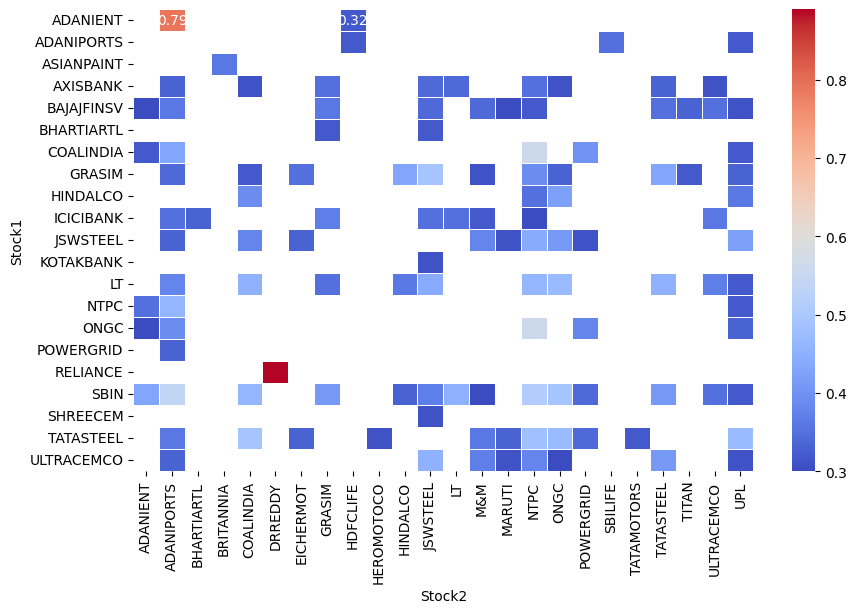

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_matrix,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)

In [25]:
cointegrated_pairs = []

for s1, s2, corr in correlated_pairs:
    score, p_value, _ = coint(merged_df[s1], merged_df[s2])
    
    if p_value < 0.05:
        cointegrated_pairs.append((s1, s2, corr, score, p_value))

# cointegrated_pairs

In [26]:
cointegrated_pairs_df = pd.DataFrame(cointegrated_pairs, columns=["Stock1", "Stock2", "Corr_Score", "CoIn_Score", "P_Value"])
cointegrated_pairs_df.sort_values("P_Value")

,Stock1,Stock2,Corr_Score,CoIn_Score,P_Value
0,BHARTIARTL,JSWSTEEL,0.32,-4.607428,0.000811
11,JSWSTEEL,EICHERMOT,0.33,-4.520441,0.001133
10,JSWSTEEL,M&M,0.38,-4.221721,0.003381
5,BAJAJFINSV,JSWSTEEL,0.34,-4.022571,0.006667
8,TATASTEEL,ADANIPORTS,0.36,-4.020674,0.006709
4,AXISBANK,ADANIPORTS,0.33,-3.960996,0.008156
3,AXISBANK,TATASTEEL,0.33,-3.863717,0.011123
1,SBIN,HINDALCO,0.33,-3.770222,0.014846
12,ADANIENT,ADANIPORTS,0.79,-3.633592,0.022251
6,LT,ADANIPORTS,0.38,-3.493268,0.032997


### Hedge Ratio

In [27]:
def get_hedge_ratio(y, x):
    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()
    print(x, y, model.params, "\n")
    return model.params[x.columns[1]]


In [28]:
hedge_ratio = {}
for s1, s2, corr, coin, _ in cointegrated_pairs:
    if not hedge_ratio.get(s1):
        hedge_ratio[s1] = {}
    hedge_ratio[s1][s2] = get_hedge_ratio(merged_df[s1], merged_df[s2])


            const  JSWSTEEL
Date                       
2022-12-05    1.0    756.60
2022-12-06    1.0    746.75
2022-12-07    1.0    738.15
2022-12-08    1.0    744.70
2022-12-09    1.0    740.40
...           ...       ...
2025-12-26    1.0   1094.40
2025-12-29    1.0   1092.60
2025-12-30    1.0   1111.60
2025-12-31    1.0   1164.80
2026-01-01    1.0   1171.50

[764 rows x 2 columns] Date
2022-12-05     844.10
2022-12-06     833.35
2022-12-07     834.00
2022-12-08     832.60
2022-12-09     834.90
               ...   
2025-12-26    2105.40
2025-12-29    2081.60
2025-12-30    2099.80
2025-12-31    2105.60
2026-01-01    2110.40
Name: BHARTIARTL, Length: 764, dtype: float64 const      -1473.423229
JSWSTEEL       3.159338
dtype: float64 

            const  HINDALCO
Date                       
2022-12-05    1.0    481.20
2022-12-06    1.0    470.00
2022-12-07    1.0    464.30
2022-12-08    1.0    471.65
2022-12-09    1.0    462.85
...           ...       ...
2025-12-26    1.0    872.90
20

dtype: float64 

            const  EICHERMOT
Date                        
2022-12-05    1.0    3344.40
2022-12-06    1.0    3299.70
2022-12-07    1.0    3259.85
2022-12-08    1.0    3322.30
2022-12-09    1.0    3358.20
...           ...        ...
2025-12-26    1.0    7324.00
2025-12-29    1.0    7272.00
2025-12-30    1.0    7192.50
2025-12-31    1.0    7312.50
2026-01-01    1.0    7348.00

[764 rows x 2 columns] Date
2022-12-05     756.60
2022-12-06     746.75
2022-12-07     738.15
2022-12-08     744.70
2022-12-09     740.40
               ...   
2025-12-26    1094.40
2025-12-29    1092.60
2025-12-30    1111.60
2025-12-31    1164.80
2026-01-01    1171.50
Name: JSWSTEEL, Length: 764, dtype: float64 const        390.724699
EICHERMOT      0.110633
dtype: float64 

            const  ADANIPORTS
Date                         
2022-12-05    1.0      893.15
2022-12-06    1.0      896.45
2022-12-07    1.0      886.75
2022-12-08    1.0      892.90
2022-12-09    1.0      890.75
...           ..

In [29]:
hedge_ratio

{'BHARTIARTL': {'JSWSTEEL': 3.1593377731223145},
 'SBIN': {'HINDALCO': 0.9682080447484351},
 'AXISBANK': {'LT': 0.17979870293764508,
  'TATASTEEL': 4.663829403016617,
  'ADANIPORTS': 0.35918136610373447},
 'BAJAJFINSV': {'JSWSTEEL': 1.5314334719514426},
 'LT': {'ADANIPORTS': 1.7659592243434492},
 'GRASIM': {'M&M': 0.49291353533739257},
 'TATASTEEL': {'ADANIPORTS': 0.0683279179758035,
  'HEROMOTOCO': 0.018370548501193656},
 'JSWSTEEL': {'M&M': 0.15624947721343785, 'EICHERMOT': 0.11063269094328401},
 'ADANIENT': {'ADANIPORTS': 0.6030309517029901}}

### Spread 

In [30]:
spread = {}
for s1, s2, corr, coin, _ in cointegrated_pairs:
    if not spread.get(s1):
        spread[s1] = {}
    spread[s1][s2] = merged_df[s1] - hedge_ratio[s1][s2] * merged_df[s2]

In [31]:
spread

{'BHARTIARTL': {'JSWSTEEL': Date
  2022-12-05   -1546.254959
  2022-12-06   -1525.885482
  2022-12-07   -1498.065177
  2022-12-08   -1520.158840
  2022-12-09   -1504.273687
                   ...     
  2025-12-26   -1352.179259
  2025-12-29   -1370.292451
  2025-12-30   -1412.119869
  2025-12-31   -1574.396638
  2026-01-01   -1590.764201
  Length: 764, dtype: float64},
 'SBIN': {'HINDALCO': Date
  2022-12-05    151.398289
  2022-12-06    153.892219
  2022-12-07    157.511005
  2022-12-08    154.994676
  2022-12-09    168.364906
                   ...    
  2025-12-26    121.151198
  2025-12-29    127.550041
  2025-12-30    117.408857
  2025-12-31    123.689927
  2026-01-01    118.252210
  Length: 764, dtype: float64},
 'AXISBANK': {'LT': Date
  2022-12-05    524.211825
  2022-12-06    528.241415
  2022-12-07    532.757555
  2022-12-08    549.600352
  2022-12-09    546.404604
                   ...    
  2025-12-26    500.500710
  2025-12-29    505.846978
  2025-12-30    517.455656
  2

In [32]:
z_score = {}
for s1, s2, corr, coin, _ in cointegrated_pairs:
    if not z_score.get(s1):
        z_score[s1] = {}
    z_score[s1][s2] = (spread[s1][s2] - spread[s1][s2].mean()) / spread[s1][s2].std()

In [33]:
z_score

{'BHARTIARTL': {'JSWSTEEL': Date
  2022-12-05   -0.582324
  2022-12-06   -0.419460
  2022-12-07   -0.197024
  2022-12-08   -0.373673
  2022-12-09   -0.246664
                  ...   
  2025-12-26    0.969402
  2025-12-29    0.824579
  2025-12-30    0.490149
  2025-12-31   -0.807330
  2026-01-01   -0.938196
  Length: 764, dtype: float64},
 'SBIN': {'HINDALCO': Date
  2022-12-05   -0.014274
  2022-12-06    0.040560
  2022-12-07    0.120128
  2022-12-08    0.064801
  2022-12-09    0.358776
                  ...   
  2025-12-26   -0.679327
  2025-12-29   -0.538634
  2025-12-30   -0.761611
  2025-12-31   -0.623507
  2026-01-01   -0.743068
  Length: 764, dtype: float64},
 'AXISBANK': {'LT': Date
  2022-12-05    0.511352
  2022-12-06    0.581154
  2022-12-07    0.659385
  2022-12-08    0.951145
  2022-12-09    0.895787
                  ...   
  2025-12-26    0.100615
  2025-12-29    0.193226
  2025-12-30    0.394317
  2025-12-31    0.701556
  2026-01-01    0.610950
  Length: 764, dtype: floa

In [34]:
# cointegrated_pairs_df[(cointegrated_pairs_df["Stock1"] == "SBIN") & (cointegrated_pairs_df["Stock2"] == "HINDALCO")]["P_Value"].values[0]

### Half Life

In [35]:
def calculate_half_life(stock_1, stock_2, beta_val):
    
    spread = merged_df[stock_1] - beta_val * merged_df[stock_2]
    
    spread_lag = spread.shift(1)
    spread_return = spread - spread_lag
    
    spread_lag = spread_lag.dropna()
    spread_return = spread_return.dropna()
    
    spread_lag = sm.add_constant(spread_lag)
    
    model = sm.OLS(spread_return, spread_lag).fit()
    
    beta = model.params.iloc[1]
    
    half_life = -np.log(2) / beta
    
    return half_life
    

In [36]:
half_lives = []
for _, row in cointegrated_pairs_df.iterrows():
    stock_1 = row["Stock1"]
    stock_2 = row["Stock2"]
    beta_val = hedge_ratio[stock_1][stock_2]
    half_life = calculate_half_life(stock_1, stock_2, beta_val)
    half_lives.append(half_life)

cointegrated_pairs_df["Half_Life"] = half_lives

In [37]:
cointegrated_pairs_df.sort_values(by="Half_Life")


,Stock1,Stock2,Corr_Score,CoIn_Score,P_Value,Half_Life
0,BHARTIARTL,JSWSTEEL,0.32,-4.607428,0.000811,12.704398
11,JSWSTEEL,EICHERMOT,0.33,-4.520441,0.001133,13.168413
10,JSWSTEEL,M&M,0.38,-4.221721,0.003381,14.929028
5,BAJAJFINSV,JSWSTEEL,0.34,-4.022571,0.006667,17.166805
4,AXISBANK,ADANIPORTS,0.33,-3.960996,0.008156,17.381415
1,SBIN,HINDALCO,0.33,-3.770222,0.014846,18.742354
8,TATASTEEL,ADANIPORTS,0.36,-4.020674,0.006709,19.091899
3,AXISBANK,TATASTEEL,0.33,-3.863717,0.011123,20.287768
2,AXISBANK,LT,0.34,-3.480772,0.034138,22.306127
9,TATASTEEL,HEROMOTOCO,0.31,-3.372334,0.045518,23.159028


In [38]:
cointegrated_pairs_df

,Stock1,Stock2,Corr_Score,CoIn_Score,P_Value,Half_Life
0,BHARTIARTL,JSWSTEEL,0.32,-4.607428,0.000811,12.704398
1,SBIN,HINDALCO,0.33,-3.770222,0.014846,18.742354
2,AXISBANK,LT,0.34,-3.480772,0.034138,22.306127
3,AXISBANK,TATASTEEL,0.33,-3.863717,0.011123,20.287768
4,AXISBANK,ADANIPORTS,0.33,-3.960996,0.008156,17.381415
5,BAJAJFINSV,JSWSTEEL,0.34,-4.022571,0.006667,17.166805
6,LT,ADANIPORTS,0.38,-3.493268,0.032997,26.853949
7,GRASIM,M&M,0.31,-3.359622,0.047037,23.170633
8,TATASTEEL,ADANIPORTS,0.36,-4.020674,0.006709,19.091899
9,TATASTEEL,HEROMOTOCO,0.31,-3.372334,0.045518,23.159028


### Rolling Z-Score

In [39]:
rolling_z_score = {}
window = 30
for s1, s2, corr, coin, p_value in cointegrated_pairs:
    if not rolling_z_score.get(s1):
        rolling_z_score[s1] = {}
    _spread = spread[s1][s2]
    rolling_mean = _spread.rolling(window).mean()
    rolling_std = _spread.rolling(window).std()
    rolling_z_score[s1][s2] = (_spread - rolling_mean) / rolling_std

In [40]:
rolling_z_score

{'BHARTIARTL': {'JSWSTEEL': Date
  2022-12-05         NaN
  2022-12-06         NaN
  2022-12-07         NaN
  2022-12-08         NaN
  2022-12-09         NaN
                  ...   
  2025-12-26    0.966364
  2025-12-29    0.736124
  2025-12-30    0.268554
  2025-12-31   -1.375508
  2026-01-01   -1.476427
  Length: 764, dtype: float64},
 'SBIN': {'HINDALCO': Date
  2022-12-05         NaN
  2022-12-06         NaN
  2022-12-07         NaN
  2022-12-08         NaN
  2022-12-09         NaN
                  ...   
  2025-12-26   -1.801979
  2025-12-29   -1.461477
  2025-12-30   -1.642542
  2025-12-31   -1.341948
  2026-01-01   -1.420403
  Length: 764, dtype: float64},
 'AXISBANK': {'LT': Date
  2022-12-05         NaN
  2022-12-06         NaN
  2022-12-07         NaN
  2022-12-08         NaN
  2022-12-09         NaN
                  ...   
  2025-12-26   -1.394989
  2025-12-29   -1.140803
  2025-12-30   -0.673899
  2025-12-31    0.028380
  2026-01-01   -0.152857
  Length: 764, dtype: floa

In [41]:
df_list = []

for stock1, inner_dict in rolling_z_score.items():
    for stock2, series in inner_dict.items():
        col_name = f"{stock1}_{stock2}"
        df_list.append(series.rename(col_name))

rolling_z_score_df = pd.concat(df_list, axis=1)

In [42]:
rolling_z_score_df

,BHARTIARTL_JSWSTEEL,SBIN_HINDALCO,AXISBANK_LT,AXISBANK_TATASTEEL,AXISBANK_ADANIPORTS,BAJAJFINSV_JSWSTEEL,LT_ADANIPORTS,GRASIM_M&M,TATASTEEL_ADANIPORTS,TATASTEEL_HEROMOTOCO,JSWSTEEL_M&M,JSWSTEEL_EICHERMOT,ADANIENT_ADANIPORTS
Date,,,,,,,,,,,,,
2022-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,0.966364,-1.801979,-1.394989,-1.130182,-1.246821,0.250515,1.117489,1.249912,0.403192,1.054473,-0.952616,-1.214163,-0.645141
2025-12-29,0.736124,-1.461477,-1.140803,-1.486545,-0.586236,0.131836,2.390557,1.759921,1.998086,1.846705,-0.784832,-1.077525,-0.684844
2025-12-30,0.268554,-1.642542,-0.673899,-1.510399,-0.089298,-0.314292,2.145911,1.136690,2.560563,1.889432,-0.421659,-0.387358,-0.547052


### Signal Generation

In [64]:
entry_threshold = 2
exit_threshold = 0.5
stop_loss = 3

signals_df = pd.DataFrame(index=rolling_z_score_df.index)

for col in rolling_z_score_df.columns:
    
    signals = []
    
    z_series = rolling_z_score_df[col]
    
    for i in range(len(z_series)):
        
        if i == 0 or pd.isna(z_series.iloc[i]):
            signals.append(None)
            continue
        
        prev_z = z_series.iloc[i-1]
        curr_z = z_series.iloc[i]
        
        # SHORT ENTRY
        if prev_z < entry_threshold and curr_z > entry_threshold:
            signals.append(-1)
        
        # LONG ENTRY
        elif prev_z > -entry_threshold and curr_z < -entry_threshold:
            signals.append(1)
        
        # EXIT
        elif abs(curr_z) < exit_threshold:
            signals.append(0)
        
        # STOP LOSS
        elif abs(curr_z) > stop_loss:
            signals.append(0)
        
        else:
            signals.append(None)
    
    signals_df[col] = signals

In [65]:
signals_df.index = rolling_z_score_df.index
signals_df

,BHARTIARTL_JSWSTEEL,SBIN_HINDALCO,AXISBANK_LT,AXISBANK_TATASTEEL,AXISBANK_ADANIPORTS,BAJAJFINSV_JSWSTEEL,LT_ADANIPORTS,GRASIM_M&M,TATASTEEL_ADANIPORTS,TATASTEEL_HEROMOTOCO,JSWSTEEL_M&M,JSWSTEEL_EICHERMOT,ADANIENT_ADANIPORTS
Date,,,,,,,,,,,,,
2022-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2025-12-29,NaN,NaN,NaN,NaN,NaN,0.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-30,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,-1.0,NaN,0.0,0.0,NaN


In [45]:
signals_df = signals_df.reindex(merged_df.index)

In [46]:
position_df = pd.DataFrame(index=signals_df.index)

for col in signals_df.columns:
    
    current_position = 0
    positions = []
    
    for signal in signals_df[col]:
        
        if signal == 1:
            current_position = 1
            
        elif signal == -1:
            current_position = -1
            
        elif signal == 0:
            current_position = 0  # EXIT must reset
        
        positions.append(current_position)
    
    position_df[col] = positions

In [47]:
returns_df = merged_df.pct_change().fillna(0)

In [48]:
position_df

,BHARTIARTL_JSWSTEEL,SBIN_HINDALCO,AXISBANK_LT,AXISBANK_TATASTEEL,AXISBANK_ADANIPORTS,BAJAJFINSV_JSWSTEEL,LT_ADANIPORTS,GRASIM_M&M,TATASTEEL_ADANIPORTS,TATASTEEL_HEROMOTOCO,JSWSTEEL_M&M,JSWSTEEL_EICHERMOT,ADANIENT_ADANIPORTS
Date,,,,,,,,,,,,,
2022-12-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-12-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-12-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-12-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-12-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0
2025-12-29,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0
2025-12-30,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0


In [49]:
pnl_df = pd.DataFrame(index=position_df.index)

In [50]:
for col in position_df.columns:
    
    s1, s2 = col.split("_")
    beta_val = hedge_ratio[s1][s2]
    pnl_df[col] = position_df[col] * (returns_df[s1] - beta_val * returns_df[s2])

pnl_df

,BHARTIARTL_JSWSTEEL,SBIN_HINDALCO,AXISBANK_LT,AXISBANK_TATASTEEL,AXISBANK_ADANIPORTS,BAJAJFINSV_JSWSTEEL,LT_ADANIPORTS,GRASIM_M&M,TATASTEEL_ADANIPORTS,TATASTEEL_HEROMOTOCO,JSWSTEEL_M&M,JSWSTEEL_EICHERMOT,ADANIENT_ADANIPORTS
Date,,,,,,,,,,,,,
2022-12-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-12-06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
2022-12-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
2022-12-08,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-12-09,0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,0.017592,0.012199,0.001829,-0.027601,-0.003280,0.013242,-0.006955,0.001411,-0.005257,-0.005388,0.003425,0.002667,0.006145
2025-12-29,0.006108,-0.007469,0.003476,0.084601,-0.010992,0.000207,-0.036707,-0.012983,0.020306,0.019035,-0.000308,-0.000859,0.001286
2025-12-30,0.046197,0.012731,0.010772,0.083375,-0.009684,0.019524,0.004964,0.009605,-0.019994,0.019835,0.014423,0.018599,0.002400


### Considering all the cointegrated pairs 

In [51]:
portfolio_returns = pnl_df.mean(axis=1)
portfolio_returns

Date
2022-12-05    0.000000
2022-12-06    0.000000
2022-12-07    0.000000
2022-12-08    0.000000
2022-12-09    0.000000
                ...   
2025-12-26    0.000771
2025-12-29    0.005054
2025-12-30    0.016365
2025-12-31    0.018169
2026-01-01    0.003664
Length: 764, dtype: float64

In [52]:
cumulative_returns = (1 + portfolio_returns).cumprod()
cumulative_returns

Date
2022-12-05    1.000000
2022-12-06    1.000000
2022-12-07    1.000000
2022-12-08    1.000000
2022-12-09    1.000000
                ...   
2025-12-26    0.753490
2025-12-29    0.757298
2025-12-30    0.769692
2025-12-31    0.783676
2026-01-01    0.786547
Length: 764, dtype: float64

In [53]:
sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252)
print("Sharpe:", sharpe)

Sharpe: -0.4013657137529224


In [54]:
cum_max = cumulative_returns.cummax()
drawdown = cumulative_returns / cum_max - 1

max_dd = drawdown.min()
print("Max Drawdown:", max_dd)



Max Drawdown: -0.2928926319554974


In [55]:
total_return = cumulative_returns.iloc[-1] - 1
print("Total Return:", total_return)


Total Return: -0.21345259455192267


### Considering only top 5 pairs with the lowest half life

In [56]:
top_five_pairs = cointegrated_pairs_df.sort_values(by="Half_Life")[:5]
top_five_pairs

,Stock1,Stock2,Corr_Score,CoIn_Score,P_Value,Half_Life
0,BHARTIARTL,JSWSTEEL,0.32,-4.607428,0.000811,12.704398
11,JSWSTEEL,EICHERMOT,0.33,-4.520441,0.001133,13.168413
10,JSWSTEEL,M&M,0.38,-4.221721,0.003381,14.929028
5,BAJAJFINSV,JSWSTEEL,0.34,-4.022571,0.006667,17.166805
4,AXISBANK,ADANIPORTS,0.33,-3.960996,0.008156,17.381415


In [57]:
pairs_list = []
for idx, row in top_five_pairs.iterrows():
    pairs_str = f'{row["Stock1"]}_{row["Stock2"]}'
    pairs_list.append(pairs_str)
pairs_list

['BHARTIARTL_JSWSTEEL',
 'JSWSTEEL_EICHERMOT',
 'JSWSTEEL_M&M',
 'BAJAJFINSV_JSWSTEEL',
 'AXISBANK_ADANIPORTS']

In [58]:
top_five_portfolio_returns = pnl_df[pairs_list].mean(axis=1)
top_five_portfolio_returns

Date
2022-12-05    0.000000
2022-12-06    0.000000
2022-12-07    0.000000
2022-12-08    0.000000
2022-12-09    0.000000
                ...   
2025-12-26    0.006729
2025-12-29   -0.001169
2025-12-30    0.017812
2025-12-31    0.031386
2026-01-01    0.002654
Length: 764, dtype: float64

In [59]:
cumulative_returns = (1 + portfolio_returns).cumprod()
cumulative_returns

Date
2022-12-05    1.000000
2022-12-06    1.000000
2022-12-07    1.000000
2022-12-08    1.000000
2022-12-09    1.000000
                ...   
2025-12-26    0.753490
2025-12-29    0.757298
2025-12-30    0.769692
2025-12-31    0.783676
2026-01-01    0.786547
Length: 764, dtype: float64

In [60]:
sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252)
print("Sharpe:", sharpe)

Sharpe: -0.4013657137529224


In [61]:
cum_max = cumulative_returns.cummax()
drawdown = cumulative_returns / cum_max - 1

max_dd = drawdown.min()
print("Max Drawdown:", max_dd)



Max Drawdown: -0.2928926319554974


In [62]:
total_return = cumulative_returns.iloc[-1] - 1
print("Total Return:", total_return)


Total Return: -0.21345259455192267
